In [33]:
# Add import 
import sys
import torch 
from torch import nn
from torch import optim
from prodigyopt import Prodigy # proddigy optimizer from https://github.com/konstmish/prodigy?tab=readme-ov-file

import tqdm
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.use("Agg")
# matplolib inline 
%matplotlib inline
# allow reload of python modules
%load_ext autoreload
%reload_ext autoreload
%autoreload 2
from dataset.RobotPathDataset.normalizer import MinMaxFeatureNormalizer

from model.models import EMA
import copy
import time

# remove all warnings
import warnings
warnings.filterwarnings("ignore")
from utils.multi_loss import ema_losses

import os
import dotenv
dotenv.load_dotenv()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


True

In [34]:
normalizer = MinMaxFeatureNormalizer()
encoder_normalizer = MinMaxFeatureNormalizer()

In [35]:
epochs = 1000
representiation_dim = 64
EXPERIMENT_NAME=r'0.1%basis-set'

In [36]:

CONFIG = {
    # Model configuration
    'representation_dim': representiation_dim, # Dimension of the representation
    'dim_mults':(1, 2, 4, 8), # Dimension multipliers for hidden layers of the model # (1, 4, 8)
    'attention':False, 
    
    # Encoder configuration
    'embeder_num_of_hidden_layers' : 1,
    'encoder_conditional_dim': representiation_dim,
    'encoder_type': 'basis_set', # 'basis_set' or 'vae'

    # encoding types
    'path_type': 'path', # 'path' or 'offset_path'
    'condition_type': 'world_img', # world_distance_field_img, world_img, world_indx

    # Hyperparameters for training
    'batch_size': 8,
    'num_epochs': epochs,
    'ema': EMA(beta=0.99), # Exponential moving average for the model weights
        ## Optimizer configuration
        'optimizer': Prodigy,
        'optimizer_kwargs': {
            'lr': 1., # ! ONLY FOR PRODIGY OPTIMIZER
            'weight_decay': 0.01, 
            'safeguard_warmup':True,
            'use_bias_correction':True,
            'betas': (0.9, 0.99),
            },
        # Scheduler configuration
        'scheduler': torch.optim.lr_scheduler.CosineAnnealingLR,
        'scheduler_kwargs': {
            # 'gamma': 0.999,
            'T_max': 10, # Total number of iterations
        },

        'multi_loss_warm_up_steps': 2000,
        'loss_weights':{
            'MSE': 0.5, # best for overfitting 1 sample is 0.004
            'ObstacleFreePathLoss': 0.4, # bround truth avg prefromance is 0.00008 with std 0.27
            'GraphBasedConsistencyLoss': 0.1, # ground truth avg prefromance is 0.00031 with std = 1.09
        },

    # Hyperparameters for diffusion process
    'noise_steps': 1000,
    'normalize': True,
    'normalizer':normalizer,
    'encoder_normalizer':encoder_normalizer,
    'cfg_scale': 3,


    # Dataset specific configuration
    'n_paths_per_world': 10,
    'n_worlds': 1,
    'n_waypoints': 64, # due to the archtechture has to be a number that is a power of 2 
    'single_world_dataset': False,
    'entire_dataset': True,
    'fraction_of_data': 0.001,

    # logging 
    'visualize_every_n_epochs': 1,
    'stats_every_n_steps': 100,
}

In [37]:
from dataset import RobotPathDataset

In [38]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
device

cuda:0


device(type='cuda', index=0)

In [39]:
if CONFIG['single_world_dataset']:
    file = os.getenv('ONE_WORLD_DATASET_PATH')
else:
    file = os.getenv('FULL_DATASET_PATH')
dataset = RobotPathDataset(file, n_paths_per_world=CONFIG['n_paths_per_world'], n_worlds=CONFIG['n_worlds'],  n_waypoints=CONFIG['n_waypoints'],   normalizer=CONFIG['normalizer'], single_world_dataset=CONFIG['single_world_dataset'], entire_dataset=CONFIG['entire_dataset'], fraction_of_data=CONFIG['fraction_of_data'])
print(f' sample shape {dataset[0]["path"].shape} with {len(dataset)} samples')
indx_sample = 5
sample = dataset[indx_sample]

data shape: torch.Size([1653, 64, 2]), min_values: tensor([0, 0], device='cuda:0'), max_values: tensor([10, 10], device='cuda:0'), n_worlds:798, samples: 1653
 sample shape torch.Size([64, 2]) with 1653 samples


# Archtechture

### encoder

In [40]:
from model import WorldIndexEmbeder, FlattenEmbeder, VAEXperiment, BPS_Encoder

In [41]:
def reset_weights(model):
    for layer in model.children():
        if hasattr(layer, 'reset_parameters'):
            layer.reset_parameters()



In [42]:
# Import pretrained vae model
model_experiment = VAEXperiment.load_from_checkpoint(r'pretrained_models/64-encoder.ckpt')
# model_experiment.freeze()
reset_weights(model_experiment)
vae_model = model_experiment.model
vae_model.to(device)
vae_model.encoder.to(device)

Sequential(
  (0): Sequential(
    (0): Conv2d(1, 4, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
  )
  (1): Sequential(
    (0): Conv2d(4, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
  )
  (2): Sequential(
    (0): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
  )
  (3): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
  )
  (4): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(

In [43]:
from model import Encoder
class wrapper_encoder(Encoder):
    def __init__(self, vae_model):
        super(wrapper_encoder, self).__init__()
        self.vae_model = vae_model
    def forward(self, x):
        results = self.vae_model.encode(x)
        mu, log_var = results
        z = self.vae_model.reparameterize(mu, log_var)
        return z

    def decode(self, z):
        return self.vae_model.decode(z)

In [44]:
embedding_dim = CONFIG['encoder_conditional_dim']
# Define the model
sample_input = sample['world_distance_field_img']

In [45]:
if CONFIG['encoder_type'] == 'vae':
    encoder = wrapper_encoder(vae_model)
elif CONFIG['encoder_type'] == 'basis_set':
    encoder = BPS_Encoder(n_bps_points=CONFIG['encoder_conditional_dim'], n_dims=2, minv=0, maxv=64, device=device)

### Model and diffusion

In [46]:
from model import Diffusion, TemporalUnet

In [47]:
# Create the UNet
transition_dim = sample['path'].shape[-1] # transition_dim is the dimension the model should predict. not the timesteps
print(transition_dim)
model = TemporalUnet(horizon=CONFIG['noise_steps'], transition_dim=transition_dim, dim=CONFIG['representation_dim'], dim_mults=CONFIG['dim_mults'],encoder=encoder, attention=CONFIG['attention'],device=device)

2
[ models/temporal ] Channel dimensions: [(2, 64), (64, 128), (128, 256), (256, 512)]
[ models/temporal ] Embedding dimensions: env encoding 32, start_pos encoding 8, end_pos encoding 8, time encoding 16
[(2, 64), (64, 128), (128, 256), (256, 512)]


In [48]:
model.to(device);
model.device

device(type='cuda', index=0)

In [49]:
# create the diffusion model
diffusion = Diffusion(input_shape=sample['path'].shape, noise_steps=CONFIG['noise_steps'], device=device)

In [50]:
# write training loop 
import torch.optim as optim
import torch.nn as nn
from utils.visualize.vae import plot_vae_reconstruciton
from utils.visualize.diffusion import plot_diffusions, plot_noise_and_predicted_noise

In [51]:
from LoggingManager import LoggingManager
logging_manager = LoggingManager(experiement_name=EXPERIMENT_NAME)
logging_manager.log_config(CONFIG);

Logging to logs/0.1%basis-set/09h-05m-20-07-2024/logs.log


In [52]:

START_FROM_CHECKPOINT = True
Checkpoint_file = os.getenv('PRETRAINED_MODEL')

optimizer = CONFIG['optimizer'](model.parameters(), **CONFIG['optimizer_kwargs'])
scheduler = CONFIG['scheduler'](optimizer, **CONFIG['scheduler_kwargs'])
ema = CONFIG['ema']
ema_model = copy.deepcopy(model).eval().requires_grad_(False)
epoch = 0
# Restart from checkpoint 
if START_FROM_CHECKPOINT:
    model, optimizer, scheduler, epoch, loss = logging_manager.load_checkpoint(model, optimizer, scheduler, filename=Checkpoint_file)
    ema.step_ema(ema_model,model)
    logging_manager.log_message(f'Restarting from epoch {epoch} with loss {loss}')
    print(f'Restarting from epoch {epoch} with loss {loss}')


Using decoupled weight decay


Restarting from epoch 38 with loss 0.05753953754901886


In [71]:
# create the diffusion model
diffusion = Diffusion(input_shape=sample['path'].shape, noise_steps=264, sigma=0.5,device=device)

In [72]:

# diffusion variables
n = 3
batch = next(iter(torch.utils.data.DataLoader(dataset, batch_size=n, shuffle=True)))

x = batch['path']
x = x.to(device)
cond = batch['world_img']
world_imgs = batch['world_img']
cond = cond.to(device)
paths = x
true_paths = batch['og_path']
x.shape, cond.shape

(torch.Size([3, 64, 2]), torch.Size([3, 64, 64]))

In [73]:
samples , intermediates = diffusion.sample_from_paths(model, n=n, paths=paths, cond=cond, normalizer=CONFIG['normalizer'])

55it [00:00, 69.54it/s]

263it [00:03, 70.13it/s]


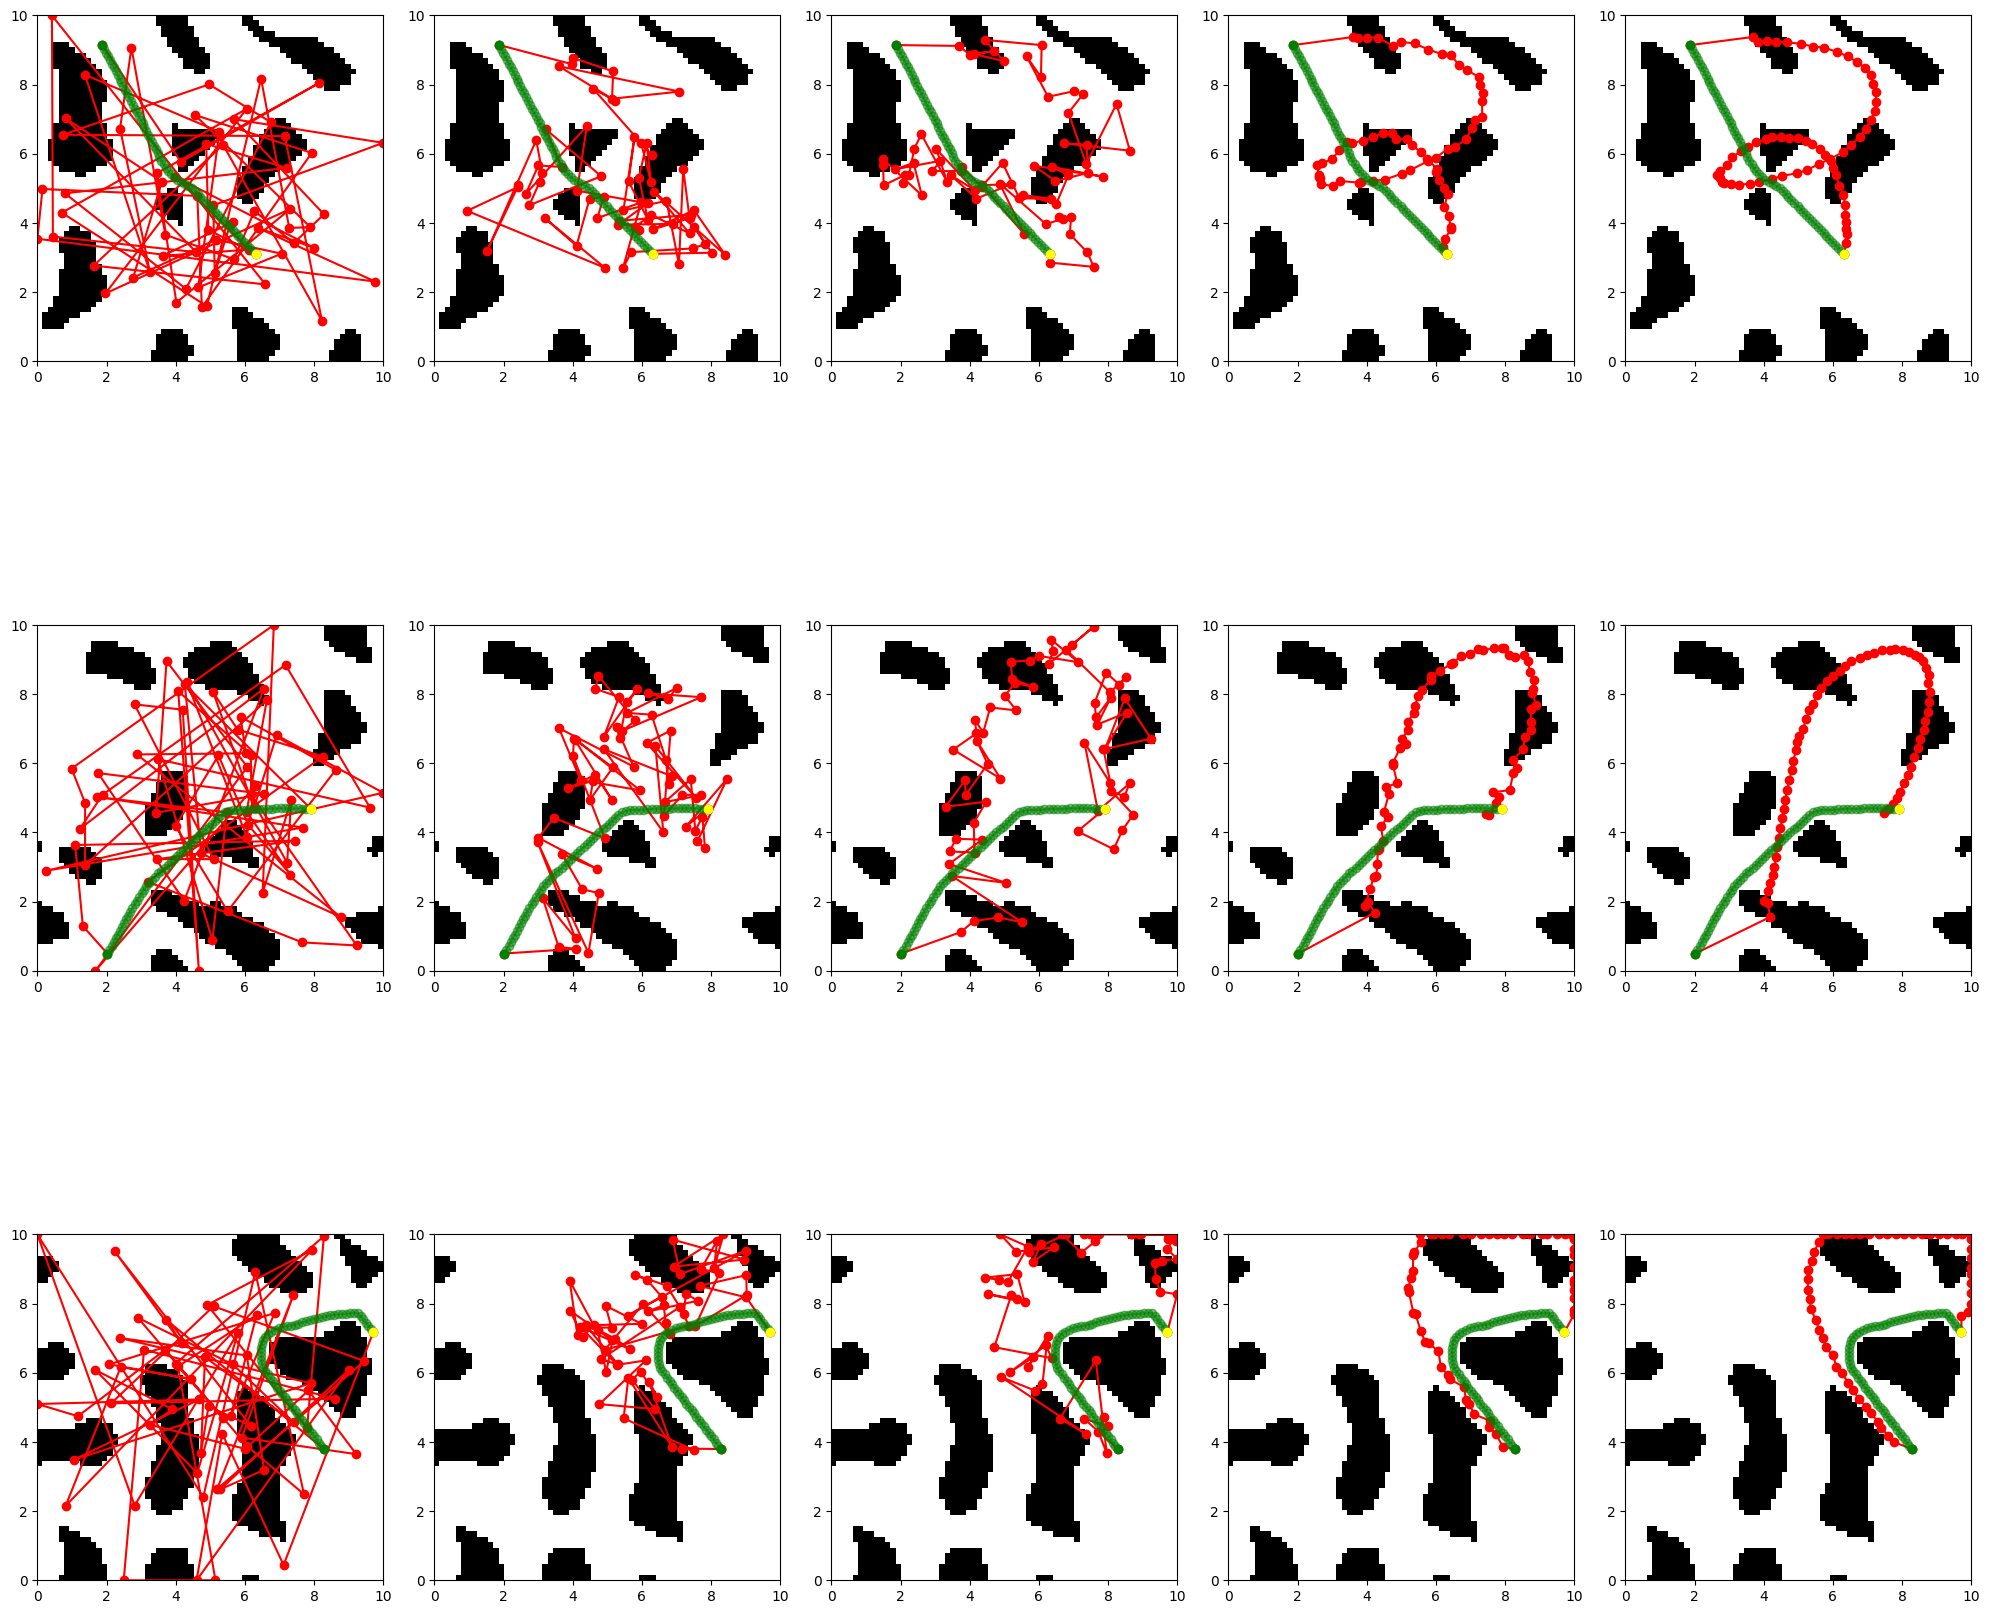

In [74]:
plot = plot_diffusions(intermediates, world_imgs=world_imgs, normalizer=CONFIG['normalizer'], true_paths=true_paths, max_plots=n);

(array([0.00422313, 0.00703855, 0.0126694 , 0.03800819, 0.07601639,
        0.10417061, 0.18863326, 0.29561929, 0.41809014, 0.56589978,
        0.79957979, 0.92908919, 1.17121547, 1.26693981, 1.32465596,
        1.3556256 , 1.24723186, 1.11349932, 0.88404245, 0.70104003,
        0.50536821, 0.3997899 , 0.27309591, 0.18722555, 0.08446265,
        0.06053157, 0.02815422, 0.02111566, 0.00703855, 0.00703855]),
 array([-1.05599258, -0.98495527, -0.91391796, -0.84288065, -0.77184333,
        -0.70080602, -0.62976871, -0.55873139, -0.48769408, -0.41665677,
        -0.34561945, -0.27458214, -0.20354483, -0.13250751, -0.0614702 ,
         0.00956711,  0.08060442,  0.15164174,  0.22267905,  0.29371636,
         0.36475368,  0.43579099,  0.5068283 ,  0.57786562,  0.64890293,
         0.71994024,  0.79097756,  0.86201487,  0.93305218,  1.00408949,
         1.07512681]),
 <BarContainer object of 30 artists>)

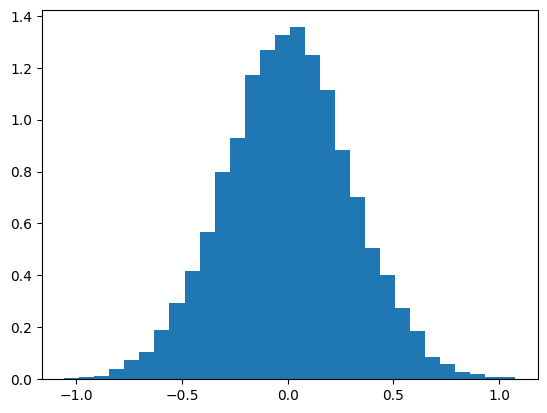

In [57]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import math

mu = 0
sigma = 0.3
n = 10000
values = np.random.randn(n) * sigma + mu
# values = np.clip(values, 0, 1)
# plot them
plt.hist(values, bins=30, density=True)

In [58]:
y

NameError: name 'y' is not defined